# Reading and Inspecting dataset

In [14]:
import pickle as pkl
import numpy as np
import pandas as pd 


with open('X_trainV3.pickle', 'rb') as f:
    X_train = pkl.load(f)

with open('Y_trainV3.pickle', 'rb') as f:
    Y_train = pkl.load(f)

with open('Y_valV3.pickle', 'rb') as f:
    Y_val = pkl.load(f)

with open('X_valV3.pickle', 'rb') as f:
     X_val = pkl.load(f)

with open('Y_testV3.pickle', 'rb') as f:
    Y_test = pkl.load(f)

with open('X_testV3.pickle', 'rb') as f:
     X_test = pkl.load(f)


Y_train = Y_train.reshape((-1,1))
Y_val = Y_val.reshape((-1,1))
Y_test = Y_test.reshape((-1,1))

X_train.shape , Y_train.shape , X_val.shape , Y_val.shape , X_test.shape , Y_test.shape

((225480, 120, 5),
 (225480, 1),
 (45000, 120, 5),
 (45000, 1),
 (135240, 120, 5),
 (135240, 1))

In [2]:
from sklearn.utils.class_weight import compute_class_weight



class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique ( np.reshape( Y_train , (np.shape(Y_train)[0]))),
                                        y = np.reshape(Y_train ,(np.shape(Y_train)[0]))                                                 
                                    )
class_weights = dict(zip(np.unique(np.reshape(Y_train ,(np.shape(Y_train)[0]))), class_weights))
class_weights


{0: 0.9998669682054011, 1: 1.0001330671989355}

In [3]:
unique, counts_train = np.unique(Y_train, return_counts=True)
unique, counts_val = np.unique(Y_val, return_counts=True)
unique, counts_test = np.unique(Y_test, return_counts=True)

print("Number of samples per class in the training dataset:")
print(dict(zip(unique, counts_train)))

print("\nNumber of samples per class in the validation dataset:")
print(dict(zip(unique, counts_val)))

print("\nNumber of samples per class in the test dataset:")
print(dict(zip(unique, counts_test)))

Number of samples per class in the training dataset:
{0: 112755, 1: 112725}

Number of samples per class in the validation dataset:
{0: 20834, 1: 24166}

Number of samples per class in the test dataset:
{0: 61154, 1: 74086}


In [4]:
import os

filepath = "parameter_tuning_LSTM_60min.csv"

# check if the file exists, create it if not
if not os.path.isfile(filepath):
    columns_name = ['LSTM_blocks', 'learning_rate', 'regularizer', 'droput', 'optimizer', 'batch size' ,
                    'train_loss' , 'val_loss' , 'train_accuracy' , 'val_accuracy', 'test_loss' , 'test_accuracy']
    df = pd.DataFrame(columns=columns_name)  # create an empty dataframe
    df.to_csv(filepath, index=False)  # save as a CSV file with no index


# Training and performance computing on Normal dataset


In [7]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 5)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 5) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


2024-11-08 19:31:56.803474: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 19:31:57.194018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-08 19:31:57.351647: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-08 19:31:57.403863: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-08 19:31:57.568655: I tensorflow/core/platform/cpu_feature_guar

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 120, 5)         │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,565 (1.02 MB)

 Trainable params: 268,555 (1.02 MB)

 Non-trainable params: 10 (40.00 B)

In [8]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]




history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), verbose=1, batch_size=batchsize, epochs=50, callbacks=callback, class_weight=class_weights)

loss, accuracy = model.evaluate(X_test, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50


2024-11-08 19:32:14.311458: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8902


441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - binary_accuracy: 0.7889 - loss: 93.2331
Epoch 1: val_binary_accuracy improved from -inf to 0.80749, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - binary_accuracy: 0.7889 - loss: 93.1940 - val_binary_accuracy: 0.8075 - val_loss: 60.4159
Epoch 2/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.8302 - loss: 56.1725
Epoch 2: val_binary_accuracy improved from 0.80749 to 0.85458, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.8303 - loss: 56.1533 - val_binary_accuracy: 0.8546 - val_loss: 43.3911
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - binary_accuracy: 0.8620 - loss: 39.1626
Epoch 3: val_binary_accuracy improved from 0.85458 to 0.86764, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.8620 - loss: 39.1531 - val_binary_accuracy: 0.8676 - val_loss: 26

In [9]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


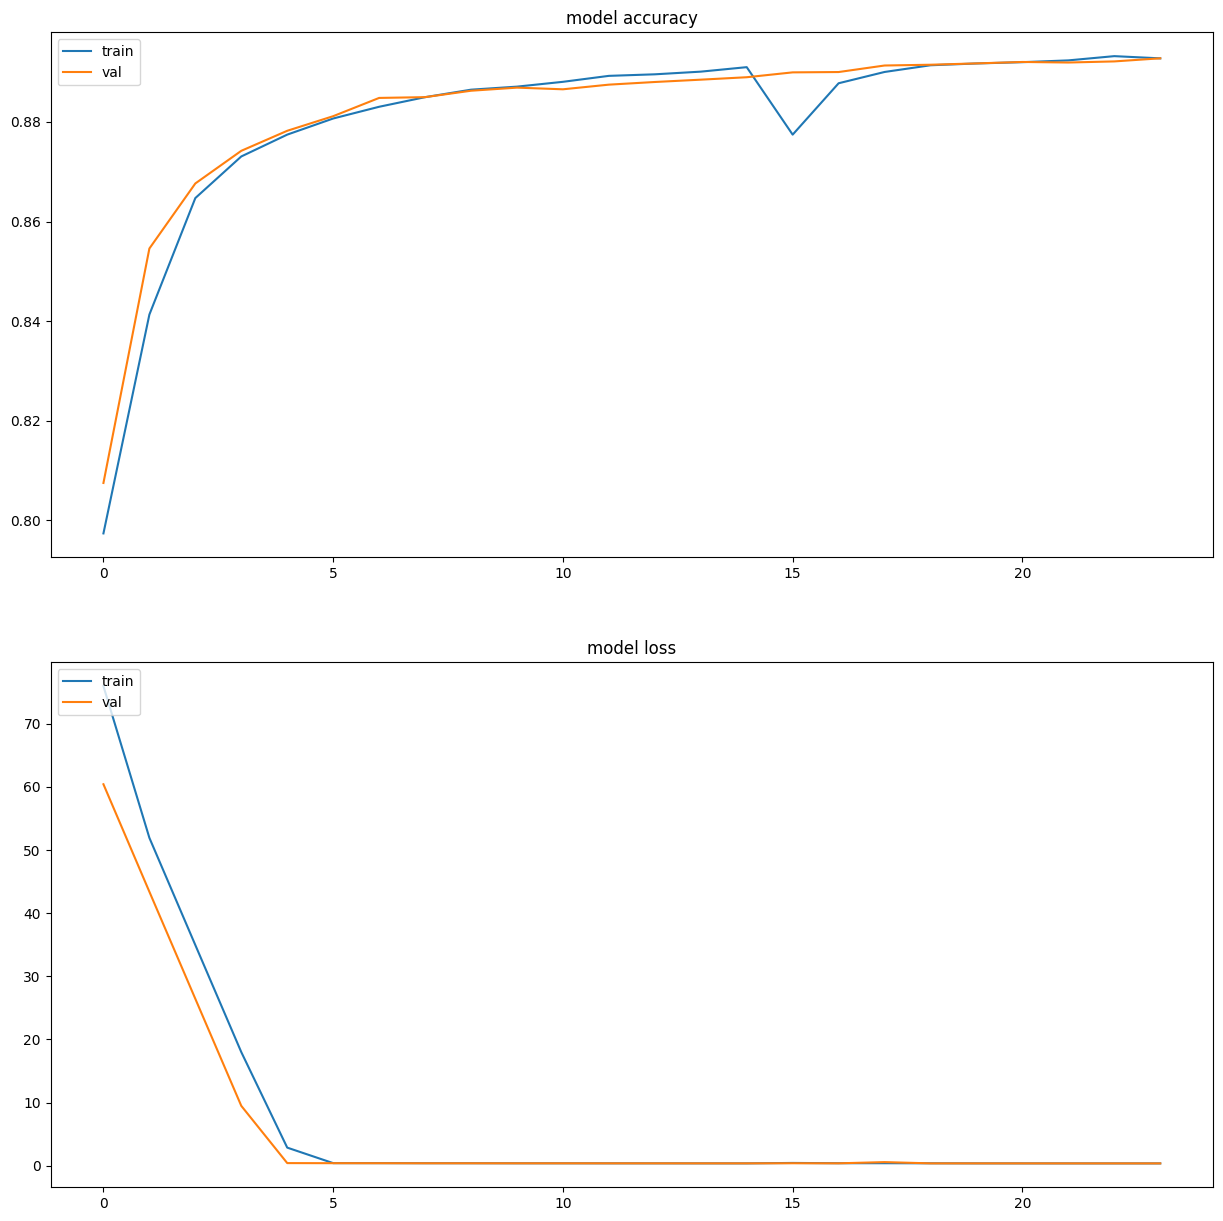

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [11]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step
F1 Score: 0.8970
Recall: 0.8863
Precision: 0.9079


# Training and Performance computing on Tampered Dataset 

#### The X_train and Y_train are shuffled simultaneously so that the temporal dependency in training data is tampered

In [12]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 5)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 5) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 120, 5)         │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,565 (1.02 MB)

 Trainable params: 268,555 (1.02 MB)

 Non-trainable params: 10 (40.00 B)

In [15]:
# Shuffle the training data
# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train = X_train[indices]
#remove the last two index of the X_train from axis 3 for all samples
# X_train_V1 = X_train[:,:,3:]
# X_val_V1 = X_val[:,:,3:]
# X_test_V1 = X_test[:,:,3:]

indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train_temp = X_train[indices]
Y_train_temp = Y_train[indices]



In [16]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]




history = model.fit(X_train_temp, Y_train_temp, validation_data=(X_val, Y_val), verbose=1, batch_size=batchsize, epochs=50, callbacks=callback, class_weight=class_weights)

loss, accuracy = model.evaluate(X_test, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.7926 - loss: 92.7404
Epoch 1: val_binary_accuracy improved from -inf to 0.81087, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - binary_accuracy: 0.7926 - loss: 92.7020 - val_binary_accuracy: 0.8109 - val_loss: 60.4140
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.8218 - loss: 56.1767
Epoch 2: val_binary_accuracy improved from 0.81087 to 0.84764, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.8218 - loss: 56.1671 - val_binary_accuracy: 0.8476 - val_loss: 43.4076
Epoch 3/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - binary_accuracy: 0.8555 - loss: 39.1841
Epoch 3: val_binary_accuracy improved from 0.84764 to 0.86307, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.8556 - loss: 39.1649 - val_binary_accuracy: 0.8631 - v

In [17]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


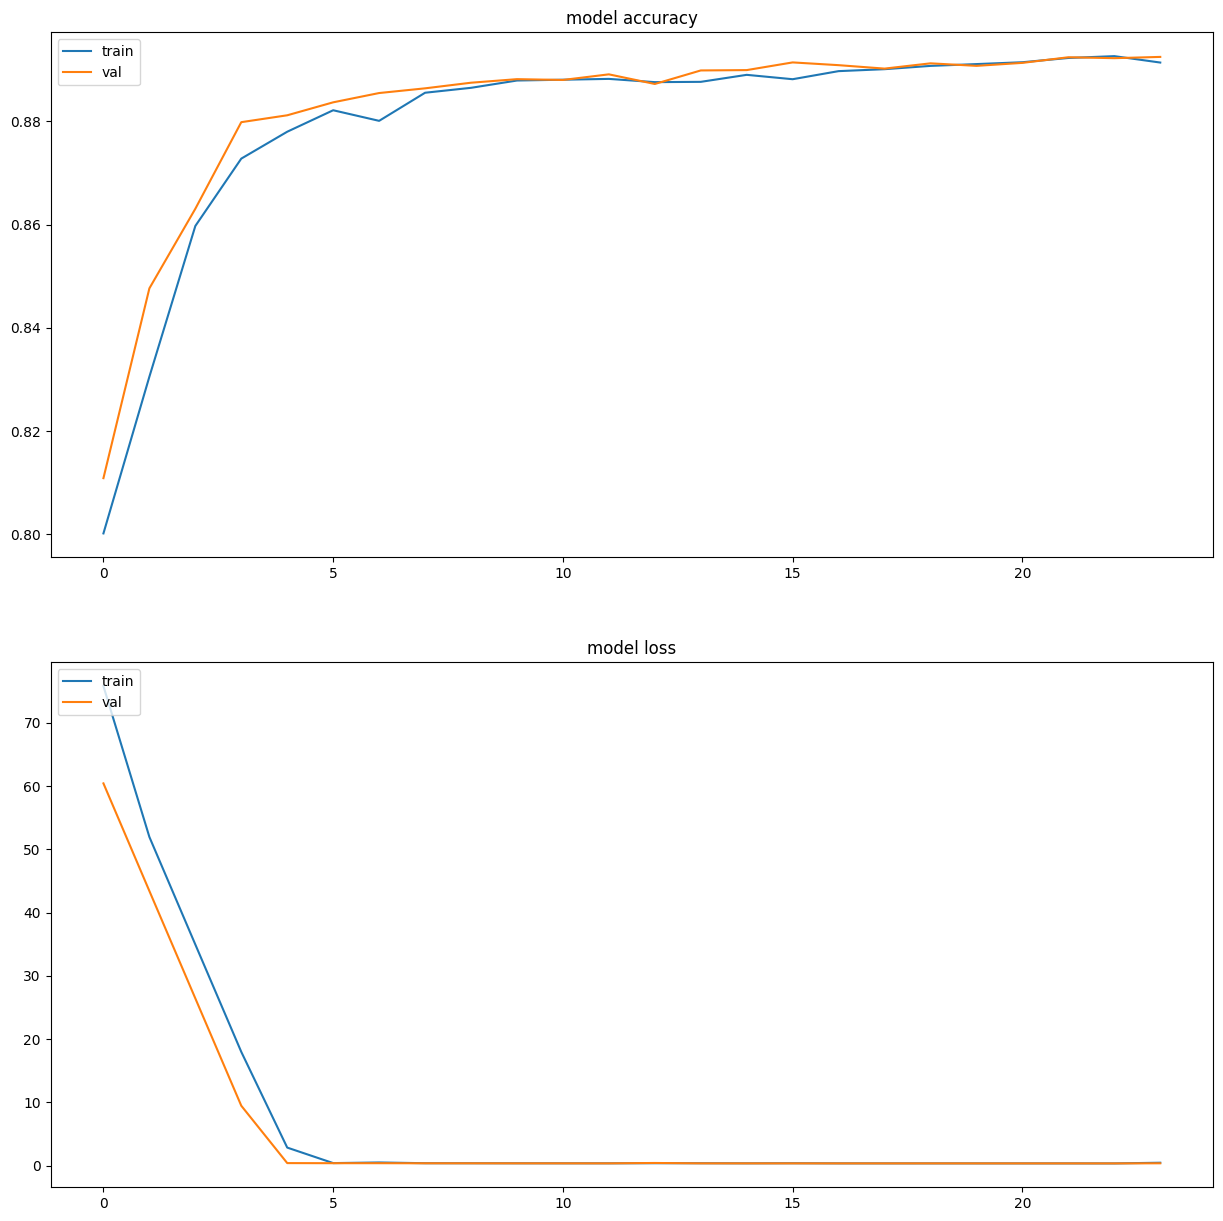

In [18]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [19]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step
F1 Score: 0.8999
Recall: 0.9128
Precision: 0.8874


#### Tampring the correlation between elements in X_train and Y_train, leads to significan drop in performance 

In [20]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 5)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 5) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_2           │ (None, 120, 5)         │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,565 (1.02 MB)

 Trainable params: 268,555 (1.02 MB)

 Non-trainable params: 10 (40.00 B)

In [21]:
# Shuffle the training data
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train_temp = X_train[indices]
#remove the last two index of the X_train from axis 3 for all samples
# X_train_V1 = X_train[:,:,3:]
# X_val_V1 = X_val[:,:,3:]
# X_test_V1 = X_test[:,:,3:]

# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train_temp = X_train[indices]
# Y_train_temp = Y_train[indices]



In [22]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]




history = model.fit(X_train_temp, Y_train, validation_data=(X_val, Y_val), verbose=1, batch_size=batchsize, epochs=50, callbacks=callback, class_weight=class_weights)

loss, accuracy = model.evaluate(X_test, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - binary_accuracy: 0.4995 - loss: 93.2768
Epoch 1: val_binary_accuracy improved from -inf to 0.46298, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - binary_accuracy: 0.4995 - loss: 93.1990 - val_binary_accuracy: 0.4630 - val_loss: 60.6735
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.4994 - loss: 56.4455
Epoch 2: val_binary_accuracy did not improve from 0.46298
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.4995 - loss: 56.4360 - val_binary_accuracy: 0.4630 - val_loss: 43.7308
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.4976 - loss: 39.5098
Epoch 3: val_binary_accuracy did not improve from 0.46298
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.4976 - loss: 39.5003 - val_binary_accuracy: 0.4630 - val_loss: 26.8011
Epoch 4/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - binary_accuracy: 0.4983 - loss: 

In [23]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


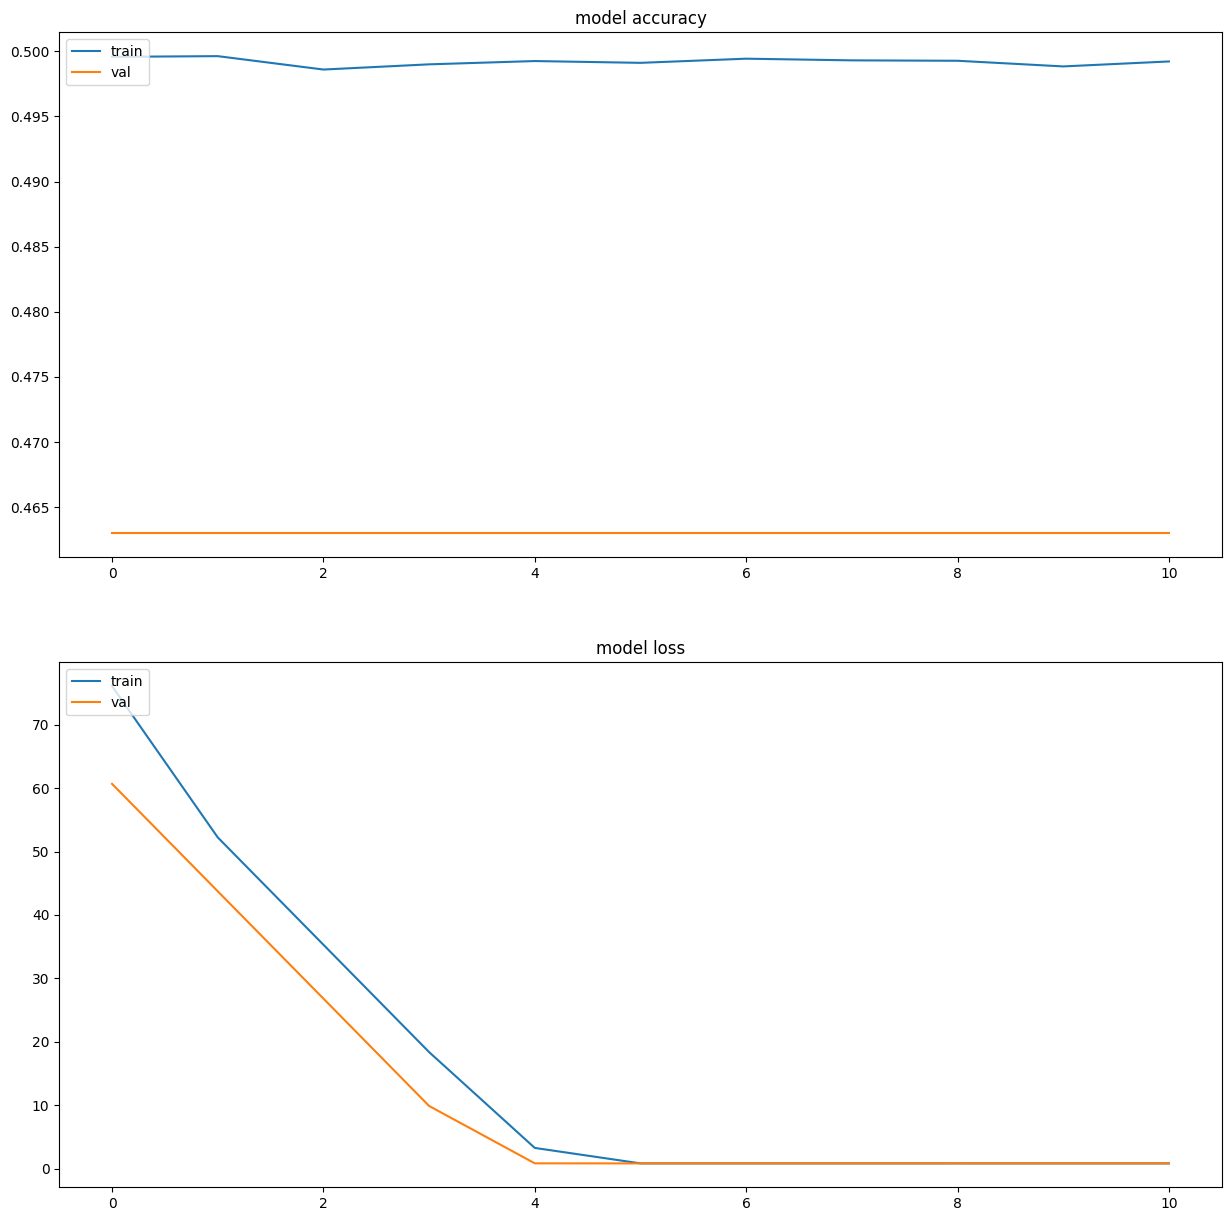

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [25]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step
F1 Score: 0.0000
Recall: 0.0000
Precision: 0.0000


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Training on only 1m return and 1week return 

In [27]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 2)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 2) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 120, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 256)            │       265,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,481 (1.01 MB)

 Trainable params: 265,477 (1.01 MB)

 Non-trainable params: 4 (16.00 B)

In [28]:
# Shuffle the training data
# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train_temp = X_train[indices]
X_train_V1 = X_train[:,:,3:]
X_val_V1 = X_val[:,:,3:]
X_test_V1 = X_test[:,:,3:]

# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train_temp = X_train[indices]
# Y_train_temp = Y_train[indices]



In [29]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]




history = model.fit(X_train_V1, Y_train, validation_data=(X_val_V1, Y_val), verbose=1, batch_size=batchsize, epochs=50, callbacks=callback, class_weight=class_weights)

loss, accuracy = model.evaluate(X_test_V1, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.7820 - loss: 80.9490
Epoch 1: val_binary_accuracy improved from -inf to 0.82827, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - binary_accuracy: 0.7821 - loss: 80.9279 - val_binary_accuracy: 0.8283 - val_loss: 60.3245
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.8426 - loss: 56.0799
Epoch 2: val_binary_accuracy improved from 0.82827 to 0.86691, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - binary_accuracy: 0.8427 - loss: 56.0703 - val_binary_accuracy: 0.8669 - val_loss: 43.3223
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.8654 - loss: 39.0995
Epoch 3: val_binary_accuracy improved from 0.86691 to 0.87178, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - binary_accuracy: 0.8654 - loss: 39.0900 - val_binary_accuracy: 0.8718 - v

In [30]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


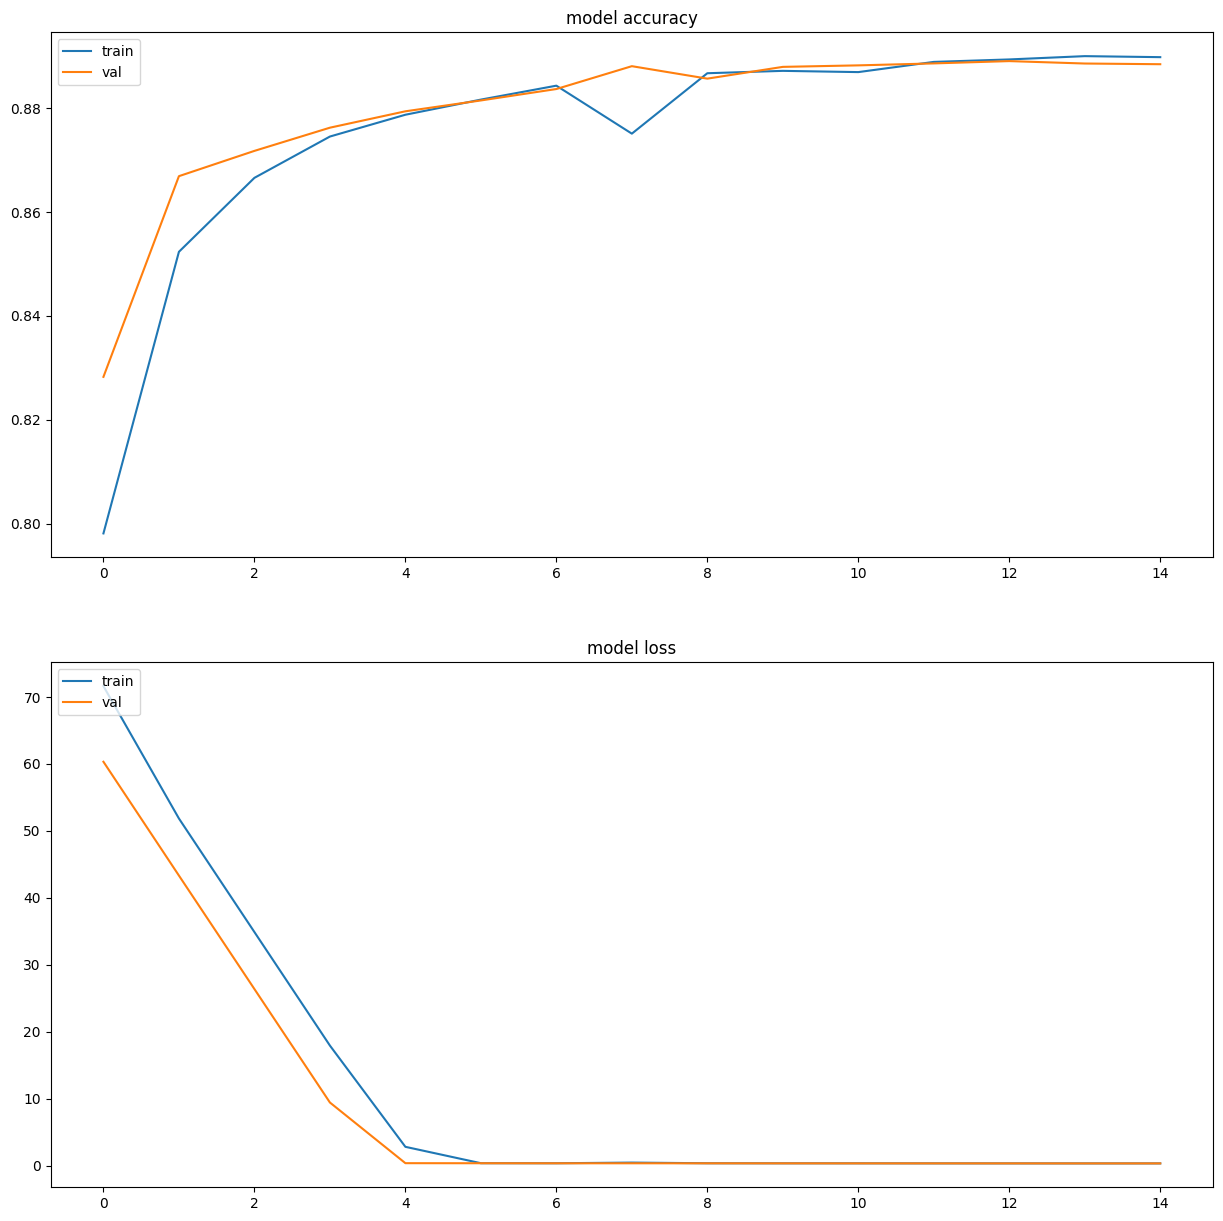

In [31]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [32]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test_V1, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step
F1 Score: 0.8910
Recall: 0.8914
Precision: 0.8906


#### training only on sentiment features

In [34]:
import tensorflow
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from tensorflow.keras import regularizers
from tensorflow import keras
import numpy as np 

#reproducibility 
np.random.seed(0)
tensorflow.random.set_seed(0)

#defining hyperparameters

LSTM_blocks = 256
regularizer = 0.3
lr = 0.0005  #I think best one is 0.0001
dropout  = 0.5
batchsize = 512
optimizer_func = 'Adam'

# Define the model
def create_model(LSTM_blocks, regularizer, dropout):
    model = Sequential()
    model.add(BatchNormalization(input_shape=(120, 3)))
    model.add(LSTM(LSTM_blocks, input_shape=(120, 3) , return_sequences=False , activation='tanh', bias_regularizer=regularizers.l1(regularizer),  kernel_regularizer=regularizers.l1(regularizer)))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.summary()
    return model 


model = create_model(LSTM_blocks, regularizer, dropout)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_6           │ (None, 120, 3)         │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 256)            │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,509 (1.02 MB)

 Trainable params: 266,503 (1.02 MB)

 Non-trainable params: 6 (24.00 B)

In [35]:
# # Shuffle the training data
# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train_temp = X_train[indices]
#remove the last two index of the X_train from axis 3 for all samples
X_train_V1 = X_train[:,:,:3]
X_val_V1 = X_val[:,:,:3]
X_test_V1 = X_test[:,:,:3]

# indices = np.arange(X_train.shape[0])
# np.random.shuffle(indices)
# X_train_temp = X_train[indices]
# Y_train_temp = Y_train[indices]



In [37]:
# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=lr,weight_decay=1e-7) if optimizer_func == 'Adam' else keras.optimizers.SGD(learning_rate=lr ,weight_decay=1e-7)

model.compile(loss='binary_crossentropy', optimizer= optimizer, metrics=['binary_accuracy' ])


checkpoint_path = 'my_best_model_LSTM_60min.keras'

checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_binary_accuracy',
                             verbose=1, 
                             save_best_only=True,
                             mode='max')


earlystopping = EarlyStopping(monitor='val_binary_accuracy', patience=10, restore_best_weights=True, min_delta=0.01)

callback = [earlystopping, checkpoint]




history = model.fit(X_train_V1, Y_train, validation_data=(X_val_V1, Y_val), verbose=1, batch_size=batchsize, epochs=50, callbacks=callback, class_weight=class_weights)

loss, accuracy = model.evaluate(X_test_V1, Y_test, batch_size=5000)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")



Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.5150 - loss: 84.9619
Epoch 1: val_binary_accuracy improved from -inf to 0.46298, saving model to my_best_model_LSTM_60min.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - binary_accuracy: 0.5150 - loss: 84.9352 - val_binary_accuracy: 0.4630 - val_loss: 60.6348
Epoch 2/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.4993 - loss: 56.4175
Epoch 2: val_binary_accuracy did not improve from 0.46298
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.4993 - loss: 56.3984 - val_binary_accuracy: 0.4630 - val_loss: 43.6947
Epoch 3/50
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.4987 - loss: 39.4820
Epoch 3: val_binary_accuracy did not improve from 0.46298
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - binary_accuracy: 0.4987 - loss: 39.4629 - val_binary_accuracy: 0.4630 - val_loss: 26.7653
Epoch 4/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - binary_accuracy: 0.4988 - loss: 

In [38]:
filepath = "parameter_tuning_LSTM_60min.csv"
parameters_to_save = pd.read_csv(filepath)

new_row = pd.DataFrame([{'LSTM_blocks' : LSTM_blocks, 'learning_rate': lr, 'regularizer': regularizer, 'droput': dropout, 
                         'optimizer': optimizer_func, 'batch size': batchsize, 'train_loss' : history.history['loss'][-1] ,
                         'val_loss' : history.history['val_loss'][-1] , 'train_accuracy' : history.history['binary_accuracy'][-1] , 
                         'val_accuracy' : history.history['val_binary_accuracy'][-1],'test_loss' : f"{loss:.4f}" , 
                         'test_accuracy' : f"{accuracy*100:.2f}%" }])

parameters_to_save = pd.concat([parameters_to_save, new_row], ignore_index=True)

parameters_to_save.to_csv(filepath, index=False)


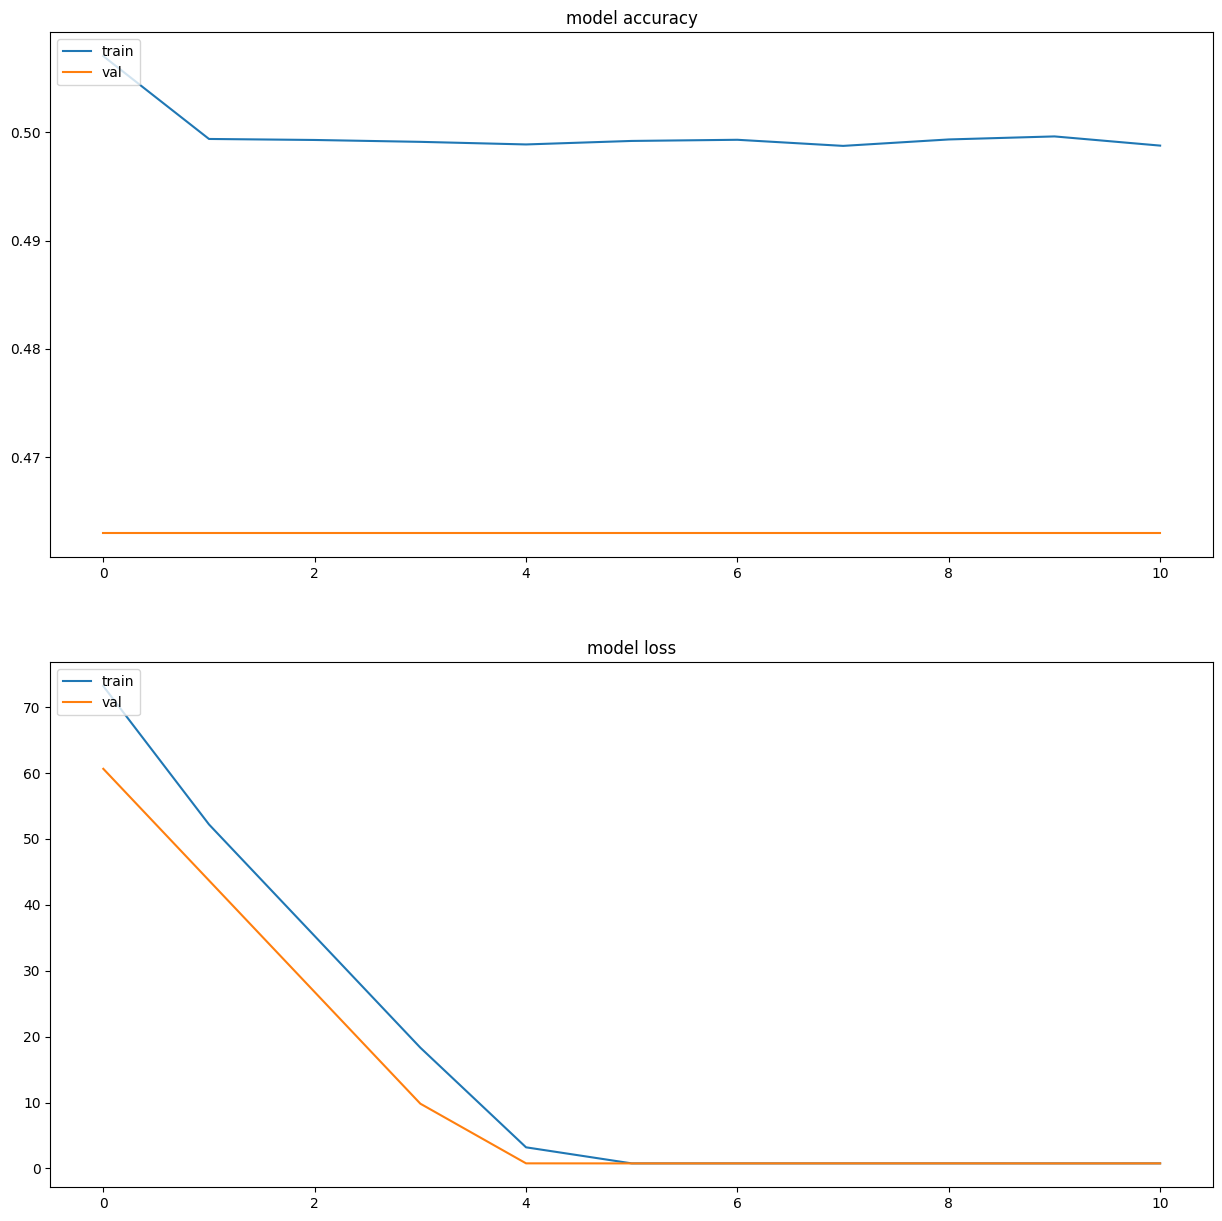

In [39]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize = (15,15))
axs = axs.flatten()
axs[0].plot(history.history['binary_accuracy'])
axs[0].plot(history.history['val_binary_accuracy'])
axs[0].set_title('model accuracy')

axs[0].legend(['train', 'val'], loc='upper left')

# summarize history for loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('model loss')

axs[1].legend(['train', 'val'], loc='upper left')


In [40]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Predict the labels for the test set
Y_pred = model.predict(X_test_V1, batch_size=5000)
Y_pred = (Y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the scores
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

# Print the results
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step
F1 Score: 0.0000
Recall: 0.0000
Precision: 0.0000


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
